In [1]:
#  PFE - Analyse des données de santé publique
#  Étape 1 : Chargement du dataset Infectious Disease
#  Compatible : Local + HDFS
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, isnan, when
from pyspark.sql.types import IntegerType, StringType

In [2]:
# 1. Créer la session Spark
# -- Option A : Local (sur ton PC, sans Hadoop)
spark = SparkSession.builder \
    .appName("PFE_SantePublique_LoadDataset") \
    .master("local[*]") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .getOrCreate()
spark.sparkContext.setLogLevel("WARN")
print(" Session Spark créée avec succès")
print(f" Version Spark : {spark.version}")

 Session Spark créée avec succès
 Version Spark : 4.0.2


In [3]:
# Option A : Fichier local
# Mets le CSV téléchargé depuis Kaggle dans le même dossier
PATH_LOCAL_TRAIN = "train.csv"
PATH_LOCAL_TEST  = "test.csv"

In [4]:
# 3. Charger le CSV dans un DataFrame Spark

df_train = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("encoding", "UTF-8") \
    .csv(PATH_LOCAL_TRAIN)

df_test = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("encoding", "UTF-8") \
    .csv(PATH_LOCAL_TEST)

print(f"\n Dataset chargé avec succès !")
print(f"   Lignes train  : {df_train.count():,}")
print(f"   Lignes test   : {df_test.count():,}")


 Dataset chargé avec succès !
   Lignes train  : 75,614
   Lignes test   : 18,904


In [5]:
 # 4. Explorer la structure du dataset
print("\n Schéma du dataset (train) :")
df_train.printSchema()

print("\n 5 premières lignes :")
df_train.show(5, truncate=False)

# Rename columns with dots to avoid Spark SQL parsing issues in describe()
df_train = df_train.withColumnRenamed("CI.lower", "CI_lower")
df_train = df_train.withColumnRenamed("CI.upper", "CI_upper")

print("\n Statistiques descriptives :")
df_train.describe().show()


 Schéma du dataset (train) :
root
 |-- _c0: integer (nullable = true)
 |-- Disease: string (nullable = true)
 |-- County: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Sex: string (nullable = true)
 |-- Count: integer (nullable = true)
 |-- Population: integer (nullable = true)
 |-- Rate: double (nullable = true)
 |-- CI.lower: double (nullable = true)
 |-- CI.upper: double (nullable = true)


 5 premières lignes :
+------+-------------+-----------+----+------+-----+----------+------+--------+--------+
|_c0   |Disease      |County     |Year|Sex   |Count|Population|Rate  |CI.lower|CI.upper|
+------+-------------+-----------+----+------+-----+----------+------+--------+--------+
|88976 |Pertussis    |Mono       |2001|Female|0    |6031      |0.0   |0.0     |61.147  |
|127888|Tuberculosis |Santa Clara|2004|Female|85   |840509    |10.113|8.078   |12.505  |
|62206 |HIV          |Merced     |2003|Female|0    |114558    |0.0   |0.0     |3.22    |
|99748 |Rabies, human|Sis

In [6]:
# 5. Vérifier les valeurs manquantes
print("\n Valeurs manquantes par colonne :")
missing = df_train.select([
    count(when(col(c).isNull() | isnan(c), c)).alias(c)
    if df_train.schema[c].dataType in [IntegerType(), "DoubleType"]
    else count(when(col(c).isNull(), c)).alias(c)
    for c in df_train.columns
])
missing.show()


 Valeurs manquantes par colonne :
+---+-------+------+----+---+-----+----------+----+--------+--------+
|_c0|Disease|County|Year|Sex|Count|Population|Rate|CI_lower|CI_upper|
+---+-------+------+----+---+-----+----------+----+--------+--------+
|  0|      0|     0|   0|  0|    0|         0|   0|       0|       0|
+---+-------+------+----+---+-----+----------+----+--------+--------+



In [7]:
# 6. Aperçu des valeurs uniques (colonnes clés)
print(f"\n Nombre de maladies distinctes : {df_train.select('Disease').distinct().count()}")
print(f" Nombre de comtés distincts    : {df_train.select('County').distinct().count()}")
print(f" Années disponibles :")
df_train.select("Year").distinct().orderBy("Year").show(20)

print(f"\n Liste des maladies :")
df_train.select("Disease").distinct().orderBy("Disease").show(50, truncate=False)


 Nombre de maladies distinctes : 65
 Nombre de comtés distincts    : 59
 Années disponibles :
+----+
|Year|
+----+
|2001|
|2002|
|2003|
|2004|
|2005|
|2006|
|2007|
|2008|
|2009|
|2010|
|2011|
|2012|
|2013|
|2014|
+----+


 Liste des maladies :
+-----------------------------------------------------------------------------+
|Disease                                                                      |
+-----------------------------------------------------------------------------+
|Amebiasis                                                                    |
|Anaplasmosis and Ehrlichiosis                                                |
|Babesiosis                                                                   |
|Botulism, Foodborne                                                          |
|Botulism, Other                                                              |
|Botulism, Wound                                                              |
|Brucellosis                       

In [8]:
# 7. Statistiques rapides sur la variable cible (Count)
print("\n Distribution de la variable cible 'Count' :")
df_train.select("Count").summary("min", "25%", "50%", "75%", "max", "mean").show()

# Top 10 maladies par nombre total de cas
print("\n Top 10 maladies les plus fréquentes :")
df_train.groupBy("Disease") \
    .sum("Count") \
    .withColumnRenamed("sum(Count)", "Total_Cases") \
    .orderBy("Total_Cases", ascending=False) \
    .show(10, truncate=False)


 Distribution de la variable cible 'Count' :
+-------+------------------+
|summary|             Count|
+-------+------------------+
|    min|                 0|
|    25%|                 0|
|    50%|                 0|
|    75%|                 1|
|    max|            115724|
|   mean|60.873991588859205|
+-------+------------------+


 Top 10 maladies les plus fréquentes :
+------------------+-----------+
|Disease           |Total_Cases|
+------------------+-----------+
|Chlamydia         |3248087    |
|Gonorrhea         |625103     |
|Campylobacteriosis|128247     |
|HIV               |101002     |
|Salmonellosis     |99293      |
|Early Syphilis    |77291      |
|Coccidioidomycosis|68990      |
|Tuberculosis      |62098      |
|Pertussis         |53547      |
|Giardiasis        |43064      |
+------------------+-----------+
only showing top 10 rows


In [9]:
# 8. Sauvegarder en format Parquet (optionnel, meilleur pour Spark)
df_train.write.mode("overwrite").parquet("data/train.parquet")
df_test.write.mode("overwrite").parquet("data/test.parquet")
print("\n Données sauvegardées en format Parquet")


 Données sauvegardées en format Parquet


In [10]:
# 9. Mettre le DataFrame en cache (pour accélérer les analyses)
df_train.cache()
print("\n DataFrame mis en cache — analyses suivantes seront plus rapides")


 DataFrame mis en cache — analyses suivantes seront plus rapides


In [11]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, DoubleType
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer,
    IndexToString,
    VectorAssembler,
    StandardScaler,
    MinMaxScaler
)
from pyspark.ml.stat import Correlation
import sys

In [12]:
# BLOC 0 — Configuration
HDFS_NAMENODE   = "hdfs://localhost:9000"
HDFS_PARQUET    = f"{HDFS_NAMENODE}/pfe/data/output/parquet"   # sortie étape 1
HDFS_OUTPUT     = f"{HDFS_NAMENODE}/pfe/data/output/processed" # sortie étape 2
LOCAL_OUTPUT    = "data/processed"                              # export CSV local

In [13]:
# BLOC 1 — Session Spark
# ============================================================

print("=" * 60)
print("  PFE Santé Publique — Preprocessing")
print("=" * 60)

spark = SparkSession.builder \
    .appName("PFE_SantePublique_Preprocessing") \
    .master("yarn") \
    .config("spark.executor.memory", "2g") \
    .config("spark.executor.cores", "2") \
    .config("spark.executor.instances", "2") \
    .config("spark.driver.memory", "1g") \
    .config("spark.hadoop.fs.defaultFS", HDFS_NAMENODE) \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f" Session Spark créée — version {spark.version}")

  PFE Santé Publique — Preprocessing
 Session Spark créée — version 4.0.2


In [14]:
# BLOC 2 — Chargement des données (depuis Parquet ou CSV)

print("\n" + "-" * 50)
print("  CHARGEMENT DES DONNÉES")
print("-" * 50)

# Local paths where data might have been saved in a previous local run
LOCAL_PARQUET_TRAIN_PATH = "data/train.parquet"
LOCAL_PARQUET_TEST_PATH = "data/test.parquet"

try:
    # Option A : charger depuis Parquet local (recommandé pour la vitesse si disponible)
    # Removed 'file://' prefix for local relative paths
    df_train = spark.read.parquet(LOCAL_PARQUET_TRAIN_PATH)
    df_test  = spark.read.parquet(LOCAL_PARQUET_TEST_PATH)
    print(" Données chargées depuis Parquet local.")
except Exception as e:
    print(f"  Échec du chargement depuis Parquet local: {e}")
    try:
        # Option B : charger depuis CSV local si Parquet local absent
        # Removed 'file://' prefix for local relative paths
        print("  Tentative de chargement depuis CSV local.")
        df_train = spark.read \
            .option("header", "true").option("inferSchema", "true") \
            .option("encoding", "UTF-8") \
            .csv(PATH_LOCAL_TRAIN) # PATH_LOCAL_TRAIN is already defined as local file
        df_test  = spark.read \
            .option("header", "true").option("inferSchema", "true") \
            .option("encoding", "UTF-8") \
            .csv(PATH_LOCAL_TEST) # PATH_LOCAL_TEST is already defined as local file
        print(" Données chargées depuis CSV local.")
    except Exception as e_csv:
        print(f"  Échec du chargement depuis CSV local: {e_csv}")
        # Original HDFS loading (if running on a cluster where HDFS is available)
        print("  Tentative de chargement depuis HDFS (cluster).")
        df_train = spark.read \
            .option("header", "true").option("inferSchema", "true") \
            .csv(f"{HDFS_NAMENODE}/pfe/data/infectious-disease-train.csv")
        df_test  = spark.read \
            .option("header", "true").option("inferSchema", "true") \
            .csv(f"{HDFS_NAMENODE}/pfe/data/infectious-disease-test.csv")
        print(" Données chargées depuis HDFS CSV.")

print(f"   Lignes train avant nettoyage : {df_train.count():,}")
print(f"   Lignes test  avant nettoyage : {df_test.count():,}")
print(f"   Colonnes : {df_train.columns}")


--------------------------------------------------
  CHARGEMENT DES DONNÉES
--------------------------------------------------
 Données chargées depuis Parquet local.
   Lignes train avant nettoyage : 75,614
   Lignes test  avant nettoyage : 18,904
   Colonnes : ['_c0', 'Disease', 'County', 'Year', 'Sex', 'Count', 'Population', 'Rate', 'CI_lower', 'CI_upper']


In [15]:
# BLOC 3 — Nettoyage : valeurs nulles et aberrantes
# ============================================================

print("\n" + "-" * 50)
print("  NETTOYAGE DES DONNÉES")
print("-" * 50)

def clean_dataframe(df, name="DataFrame"):
    total_avant = df.count()

    # 3.1 Supprimer les lignes entièrement nulles
    df = df.dropna(how="all")

    # 3.2 Supprimer les lignes où les colonnes clés sont nulles
    df = df.dropna(subset=["Disease", "County", "Year", "Sex", "Count"])

    # 3.3 Convertir les colonnes numériques au bon type
    df = df.withColumn("Year",  F.col("Year").cast(IntegerType()))
    df = df.withColumn("Count", F.col("Count").cast(IntegerType()))

    # 3.4 Supprimer les valeurs aberrantes
    df = df.filter(F.col("Count") >= 0)           # Count ne peut pas être négatif
    df = df.filter(F.col("Year").between(1990, 2030))  # Années cohérentes
    df = df.filter(F.col("Disease").isNotNull() & (F.col("Disease") != ""))
    df = df.filter(F.col("County").isNotNull()  & (F.col("County")  != ""))

    # 3.5 Nettoyer les espaces dans les chaînes
    df = df.withColumn("Disease", F.trim(F.col("Disease")))
    df = df.withColumn("County",  F.trim(F.col("County")))
    df = df.withColumn("Sex",     F.trim(F.col("Sex")))

    # 3.6 Uniformiser la casse
    df = df.withColumn("Disease", F.initcap(F.col("Disease")))
    df = df.withColumn("Sex",     F.initcap(F.col("Sex")))

    total_apres = df.count()
    supprimes   = total_avant - total_apres
    print(f" {name} : {total_avant:,} → {total_apres:,} lignes "
          f"({supprimes:,} supprimées, {round(supprimes/total_avant*100,2)}%)")
    return df

# Rename columns with dots for df_test before cleaning
df_test = df_test.withColumnRenamed("CI.lower", "CI_lower")
df_test = df_test.withColumnRenamed("CI.upper", "CI_upper")

df_train = clean_dataframe(df_train, "Train")
df_test  = clean_dataframe(df_test,  "Test")


--------------------------------------------------
  NETTOYAGE DES DONNÉES
--------------------------------------------------
 Train : 75,614 → 75,614 lignes (0 supprimées, 0.0%)
 Test : 18,904 → 18,904 lignes (0 supprimées, 0.0%)


In [16]:
# BLOC 4 — StringIndexer : encodage des variables catégorielles
# ============================================================
# StringIndexer convertit chaque valeur unique en entier
# Exemple : "Malaria" → 0, "Tuberculosis" → 1, "COVID" → 2 ...
# ============================================================

print("\n" + "-" * 50)
print("  ENCODAGE CATÉGORIEL (StringIndexer)")
print("-" * 50)

# 4.1 Indexer Disease
disease_indexer = StringIndexer(
    inputCol  = "Disease",
    outputCol = "Disease_idx",
    handleInvalid = "keep"   # garde les nouvelles valeurs du test set
)

# 4.2 Indexer County
county_indexer = StringIndexer(
    inputCol  = "County",
    outputCol = "County_idx",
    handleInvalid = "keep"
)

# 4.3 Indexer Sex
sex_indexer = StringIndexer(
    inputCol  = "Sex",
    outputCol = "Sex_idx",
    handleInvalid = "keep"
)

# 4.4 Construire et entraîner le Pipeline d'encodage sur le train
encoding_pipeline = Pipeline(stages=[
    disease_indexer,
    county_indexer,
    sex_indexer
])

print("   Entraînement du StringIndexer sur le train...")
encoding_model = encoding_pipeline.fit(df_train)

# 4.5 Transformer train ET test avec le même modèle
df_train_encoded = encoding_model.transform(df_train)
df_test_encoded  = encoding_model.transform(df_test)

print(" Encodage terminé")
print("   Nouvelles colonnes : Disease_idx, County_idx, Sex_idx")
print("\n   Aperçu du mapping Disease (5 premières valeurs) :")
df_train_encoded.select("Disease", "Disease_idx") \
    .distinct().orderBy("Disease_idx").show(5, truncate=False)


--------------------------------------------------
  ENCODAGE CATÉGORIEL (StringIndexer)
--------------------------------------------------
   Entraînement du StringIndexer sur le train...
 Encodage terminé
   Nouvelles colonnes : Disease_idx, County_idx, Sex_idx

   Aperçu du mapping Disease (5 premières valeurs) :
+----------------------------------------+-----------+
|Disease                                 |Disease_idx|
+----------------------------------------+-----------+
|Cryptosporidiosis                       |0.0        |
|Lyme Disease                            |1.0        |
|Salmonellosis                           |2.0        |
|Ciguatera Fish Poisoning                |3.0        |
|Toxic Shock Syndrome (non-streptococcal)|4.0        |
+----------------------------------------+-----------+
only showing top 5 rows


In [17]:
# BLOC 5 — Feature Engineering : ajout de variables utiles
# ============================================================

print("\n" + "-" * 50)
print("  FEATURE ENGINEERING")
print("-" * 50)

def add_features(df):
    # 5.1 Décennie (2001-2010 → 2000, 2011-2014 → 2010)
    df = df.withColumn("Decade",
        (F.floor(F.col("Year") / 10) * 10).cast(IntegerType()))

    # 5.2 Taux de croissance simulé par rapport à l'année de base 2001
    # (utilisé comme feature contextuelle)
    df = df.withColumn("Year_norm",
        (F.col("Year") - 2001).cast(DoubleType()))

    # 5.3 Log du Count (utile pour réduire l'asymétrie)
    df = df.withColumn("Count_log",
        F.log1p(F.col("Count").cast(DoubleType())))

    return df

df_train_encoded = add_features(df_train_encoded)
df_test_encoded  = add_features(df_test_encoded)

print(" Features ajoutées : Decade, Year_norm, Count_log")


--------------------------------------------------
  FEATURE ENGINEERING
--------------------------------------------------
 Features ajoutées : Decade, Year_norm, Count_log


In [18]:
# BLOC 6 — VectorAssembler : assembler toutes les features ML
# VectorAssembler combine plusieurs colonnes en UN seul vecteur
# C'est obligatoire pour les algorithmes ML de Spark

print("\n" + "-" * 50)
print("  ASSEMBLAGE DES FEATURES (VectorAssembler)")
print("-" * 50)

# Liste de toutes les features d'entrée pour le modèle ML
FEATURE_COLS = [
    "Disease_idx",   # maladie encodée
    "County_idx",    # comté encodé
    "Year",          # année
    "Sex_idx",       # sexe encodé
    "Decade",        # décennie
    "Year_norm",     # année normalisée
]

# Variable cible
TARGET_COL = "Count"

assembler = VectorAssembler(
    inputCols  = FEATURE_COLS,
    outputCol  = "features_raw",
    handleInvalid = "keep"
)

df_train_assembled = assembler.transform(df_train_encoded)
df_test_assembled  = assembler.transform(df_test_encoded)

print(f" VectorAssembler : {len(FEATURE_COLS)} features → vecteur 'features_raw'")
print(f"   Features utilisées : {FEATURE_COLS}")


--------------------------------------------------
  ASSEMBLAGE DES FEATURES (VectorAssembler)
--------------------------------------------------
 VectorAssembler : 6 features → vecteur 'features_raw'
   Features utilisées : ['Disease_idx', 'County_idx', 'Year', 'Sex_idx', 'Decade', 'Year_norm']


In [19]:
# BLOC 7 — StandardScaler : normalisation des features
# StandardScaler centre (mean=0) et réduit (std=1) chaque feature
# Évite que les grandes valeurs dominent le modèle

print("\n" + "-" * 50)
print("  NORMALISATION (StandardScaler)")
print("-" * 50)

scaler = StandardScaler(
    inputCol  = "features_raw",
    outputCol = "features",
    withMean  = True,    # centrer : soustrait la moyenne
    withStd   = True     # réduire : divise par l'écart type
)

print("   Entraînement du StandardScaler sur le train...")
scaler_model = scaler.fit(df_train_assembled)

df_train_scaled = scaler_model.transform(df_train_assembled)
df_test_scaled  = scaler_model.transform(df_test_assembled)

print(" Normalisation terminée — colonne 'features' créée")


--------------------------------------------------
  NORMALISATION (StandardScaler)
--------------------------------------------------
   Entraînement du StandardScaler sur le train...
 Normalisation terminée — colonne 'features' créée


In [20]:
# BLOC 8 — Sélection des colonnes finales
print("\n" + "-" * 50)
print("  SÉLECTION DES COLONNES FINALES")
print("-" * 50)

# Colonnes à garder dans le CSV final (lisibles par scikit-learn)
FINAL_COLS = [
    "Disease", "Disease_idx",
    "County",  "County_idx",
    "Year",    "Year_norm",
    "Sex",     "Sex_idx",
    "Decade",
    "Count",   "Count_log"   # Count = variable cible
]

df_train_final = df_train_scaled.select(FINAL_COLS)
df_test_final  = df_test_scaled.select(FINAL_COLS)

print(f" Colonnes finales sélectionnées : {FINAL_COLS}")
print(f"\n   Lignes train final : {df_train_final.count():,}")
print(f"   Lignes test  final : {df_test_final.count():,}")

print("\n Aperçu du DataFrame final (train) :")
df_train_final.show(5, truncate=False)


--------------------------------------------------
  SÉLECTION DES COLONNES FINALES
--------------------------------------------------
 Colonnes finales sélectionnées : ['Disease', 'Disease_idx', 'County', 'County_idx', 'Year', 'Year_norm', 'Sex', 'Sex_idx', 'Decade', 'Count', 'Count_log']

   Lignes train final : 75,614
   Lignes test  final : 18,904

 Aperçu du DataFrame final (train) :
+-------------+-----------+-----------+----------+----+---------+------+-------+------+-----+-----------------+
|Disease      |Disease_idx|County     |County_idx|Year|Year_norm|Sex   |Sex_idx|Decade|Count|Count_log        |
+-------------+-----------+-----------+----------+----+---------+------+-------+------+-----+-----------------+
|Pertussis    |24.0       |Mono       |50.0      |2001|0.0      |Female|1.0    |2000  |0    |0.0              |
|Tuberculosis |12.0       |Santa Clara|33.0      |2004|3.0      |Female|1.0    |2000  |85   |4.454347296253507|
|Hiv          |10.0       |Merced     |39.0    

In [21]:
# BLOC 9 — Vérification qualité avant export

print("\n" + "-" * 50)
print("  VÉRIFICATION QUALITÉ")
print("-" * 50)

# 9.1 Vérifier qu'il n'y a plus de nulls
print("   Valeurs nulles restantes :")
for col_name in FINAL_COLS:
    null_count = df_train_final.filter(F.col(col_name).isNull()).count()
    status = "✅" if null_count == 0 else "❌"
    print(f"   {status} {col_name:<20} : {null_count} nulls")

# 9.2 Statistiques finales de la variable cible
print("\n Statistiques finales de Count (variable cible) :")
df_train_final.select("Count").summary(
    "count", "min", "25%", "50%", "75%", "max", "mean"
).show()


--------------------------------------------------
  VÉRIFICATION QUALITÉ
--------------------------------------------------
   Valeurs nulles restantes :
   ✅ Disease              : 0 nulls
   ✅ Disease_idx          : 0 nulls
   ✅ County               : 0 nulls
   ✅ County_idx           : 0 nulls
   ✅ Year                 : 0 nulls
   ✅ Year_norm            : 0 nulls
   ✅ Sex                  : 0 nulls
   ✅ Sex_idx              : 0 nulls
   ✅ Decade               : 0 nulls
   ✅ Count                : 0 nulls
   ✅ Count_log            : 0 nulls

 Statistiques finales de Count (variable cible) :
+-------+------------------+
|summary|             Count|
+-------+------------------+
|  count|             75614|
|    min|                 0|
|    25%|                 0|
|    50%|                 0|
|    75%|                 1|
|    max|            115724|
|   mean|60.873991588859205|
+-------+------------------+



In [22]:
# BLOC 10 — Export CSV propre (pour scikit-learn)

print("\n" + "-" * 50)
print("  EXPORT CSV PROPRE")
print("-" * 50)

import os

# Get absolute path for LOCAL_OUTPUT
ABS_LOCAL_OUTPUT = os.path.abspath(LOCAL_OUTPUT)

# Create local output directories if they don't exist
os.makedirs(f"{ABS_LOCAL_OUTPUT}/csv", exist_ok=True)
os.makedirs(f"{ABS_LOCAL_OUTPUT}/parquet", exist_ok=True)

# Option A : Sauvegarder en local en CSV
df_train_final.coalesce(1) \
    .write.mode("overwrite") \
    .option("header", "true") \
    .csv(f"file://{ABS_LOCAL_OUTPUT}/csv/train")

df_test_final.coalesce(1) \
    .write.mode("overwrite") \
    .option("header", "true") \
    .csv(f"file://{ABS_LOCAL_OUTPUT}/csv/test")

print(f" CSV sauvegardé en local : {ABS_LOCAL_OUTPUT}/csv/")

# Option B : Sauvegarder en local en Parquet (plus rapide pour Spark)
df_train_final.write.mode("overwrite").parquet(f"file://{ABS_LOCAL_OUTPUT}/parquet/train")
df_test_final.write.mode("overwrite").parquet(f"file://{ABS_LOCAL_OUTPUT}/parquet/test")

print(f" Parquet sauvegardé en local : {ABS_LOCAL_OUTPUT}/parquet/")

# Information sur la récupération des fichiers
print("\n💡 Les fichiers CSV et Parquet ont été sauvegardés localement.")
print(f"   Vous pouvez les trouver dans les dossiers : {ABS_LOCAL_OUTPUT}/csv et {ABS_LOCAL_OUTPUT}/parquet")


--------------------------------------------------
  EXPORT CSV PROPRE
--------------------------------------------------
 CSV sauvegardé en local : /content/data/processed/csv/
 Parquet sauvegardé en local : /content/data/processed/parquet/

💡 Les fichiers CSV et Parquet ont été sauvegardés localement.
   Vous pouvez les trouver dans les dossiers : /content/data/processed/csv et /content/data/processed/parquet


In [23]:
# BLOC 11 — Résumé final
# ============================================================

print("\n" + "=" * 60)
print("  RÉSUMÉ DU PREPROCESSING")
print("=" * 60)
print(f"  Nettoyage      : dropna, filtres aberrants, trim, initcap")
print(f"  Encodage       : StringIndexer → Disease_idx, County_idx, Sex_idx")
print(f"  Features eng.  : Decade, Year_norm, Count_log")
print(f"  Assemblage     : VectorAssembler → features_raw ({len(FEATURE_COLS)} cols)")
print(f"  Normalisation  : StandardScaler → features (mean=0, std=1)")
print(f"  Colonnes finales : {len(FINAL_COLS)} colonnes")
print(f"  Lignes train   : {df_train_final.count():,}")
print(f"  Lignes test    : {df_test_final.count():,}")
print(f"  Export HDFS    : {HDFS_OUTPUT}")
print("=" * 60)
print("\n Preprocessing terminé — Passe à 03_eda_analysis.py (Étape 3)")

# spark.stop()


  RÉSUMÉ DU PREPROCESSING
  Nettoyage      : dropna, filtres aberrants, trim, initcap
  Encodage       : StringIndexer → Disease_idx, County_idx, Sex_idx
  Features eng.  : Decade, Year_norm, Count_log
  Assemblage     : VectorAssembler → features_raw (6 cols)
  Normalisation  : StandardScaler → features (mean=0, std=1)
  Colonnes finales : 11 colonnes
  Lignes train   : 75,614
  Lignes test    : 18,904
  Export HDFS    : hdfs://localhost:9000/pfe/data/output/processed

 Preprocessing terminé — Passe à 03_eda_analysis.py (Étape 3)


In [24]:
#  Étape 3 : EDA — Analyse Exploratoire avec affichage graphiques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

In [25]:
# CONFIGURATION

OUTPUT_DIR = "outputs/graphs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi"       : 120,
    "savefig.dpi"      : 150,
    "savefig.bbox"     : "tight",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

In [26]:
import os

# Function to find the single CSV part file within a Spark-generated directory
def get_spark_single_csv_path(spark_output_dir):
    files = os.listdir(spark_output_dir)
    csv_files = [f for f in files if f.startswith('part-') and f.endswith('.csv')]
    if len(csv_files) == 1:
        return os.path.join(spark_output_dir, csv_files[0])
    elif len(csv_files) > 1:
        # This should not happen with coalesce(1), but good for robustness
        raise ValueError(f"Multiple CSV part files found in {spark_output_dir}. Please inspect the output.")
    else:
        raise FileNotFoundError(f"No CSV part files found in {spark_output_dir}.")

try:
    # Correct path to the processed CSV directory using ABS_LOCAL_OUTPUT from previous cell
    processed_train_csv_dir = os.path.join(ABS_LOCAL_OUTPUT, "csv", "train")
    processed_train_file_path = get_spark_single_csv_path(processed_train_csv_dir)
    df = pd.read_csv(processed_train_file_path)
    print(f" Données chargées : {df.shape[0]:,} lignes depuis le fichier traité")
except (FileNotFoundError, ValueError) as e: # Catch ValueError from get_spark_single_csv_path as well
    print(f"  Fichier nettoyé introuvable ou erreur de lecture ({e}) → Tentative de chargement CSV brut")
    try:
        # Fallback to raw Kaggle CSV, using the correct variable PATH_LOCAL_TRAIN
        df = pd.read_csv(PATH_LOCAL_TRAIN)
        df["Count"] = pd.to_numeric(df["Count"], errors="coerce").fillna(0).astype(int)
        df = df[df["Count"] >= 0]
        print(f" Données chargées : {df.shape[0]:,} lignes depuis le fichier brut")
    except FileNotFoundError as e_raw:
        print(f"  Erreur fatale: Fichier CSV brut introuvable non plus ({e_raw})")
        raise # Re-raise if even the raw file cannot be found

print(f"   Colonnes disponibles : {list(df.columns)}")
print(f"   Période : {df['Year'].min()} – {df['Year'].max()}")
print(f"   Maladies : {df['Disease'].nunique()} | Comtés : {df['County'].nunique()}")

 Données chargées : 75,614 lignes depuis le fichier traité
   Colonnes disponibles : ['Disease', 'Disease_idx', 'County', 'County_idx', 'Year', 'Year_norm', 'Sex', 'Sex_idx', 'Decade', 'Count', 'Count_log']
   Période : 2001 – 2014
   Maladies : 65 | Comtés : 59



 Graphique 1 : Top 15 maladies...
    Sauvegardé dans outputs/graphs/


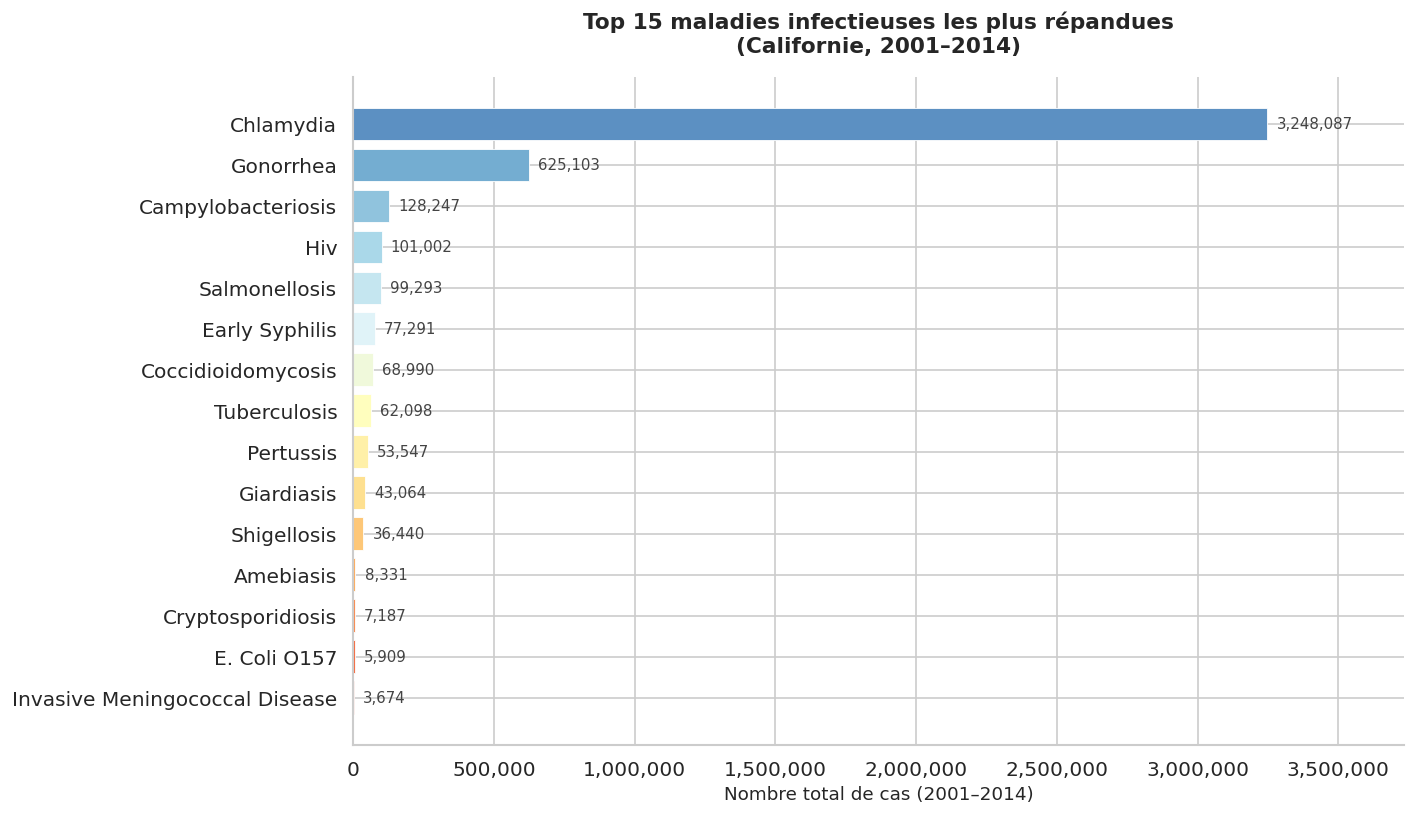

In [27]:
# GRAPHIQUE 1 — Top 15 maladies par nombre total de cas

print("\n Graphique 1 : Top 15 maladies...")

top15 = (
    df.groupby("Disease")["Count"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
top15.columns = ["Disease", "Total_Cases"]

fig1, ax1 = plt.subplots(figsize=(12, 7))
colors = plt.cm.RdYlBu_r(np.linspace(0.15, 0.85, len(top15)))
bars = ax1.barh(
    top15["Disease"][::-1],
    top15["Total_Cases"][::-1],
    color=colors[::-1],
    edgecolor="white",
    linewidth=0.5
)
for bar, val in zip(bars, top15["Total_Cases"][::-1]):
    ax1.text(
        bar.get_width() + top15["Total_Cases"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,.0f}", va="center", ha="left", fontsize=9, color="#444"
    )
ax1.set_xlabel("Nombre total de cas (2001–2014)", fontsize=11)
ax1.set_title("Top 15 maladies infectieuses les plus répandues\n(Californie, 2001–2014)",
              fontsize=13, fontweight="bold", pad=15)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax1.set_xlim(0, top15["Total_Cases"].max() * 1.15)
fig1.tight_layout()
fig1.savefig(f"{OUTPUT_DIR}/01_top15_maladies.png")
print("    Sauvegardé dans outputs/graphs/")
plt.show()

 Graphique 2 : Évolution annuelle...
   ✅ Sauvegardé dans outputs/graphs/


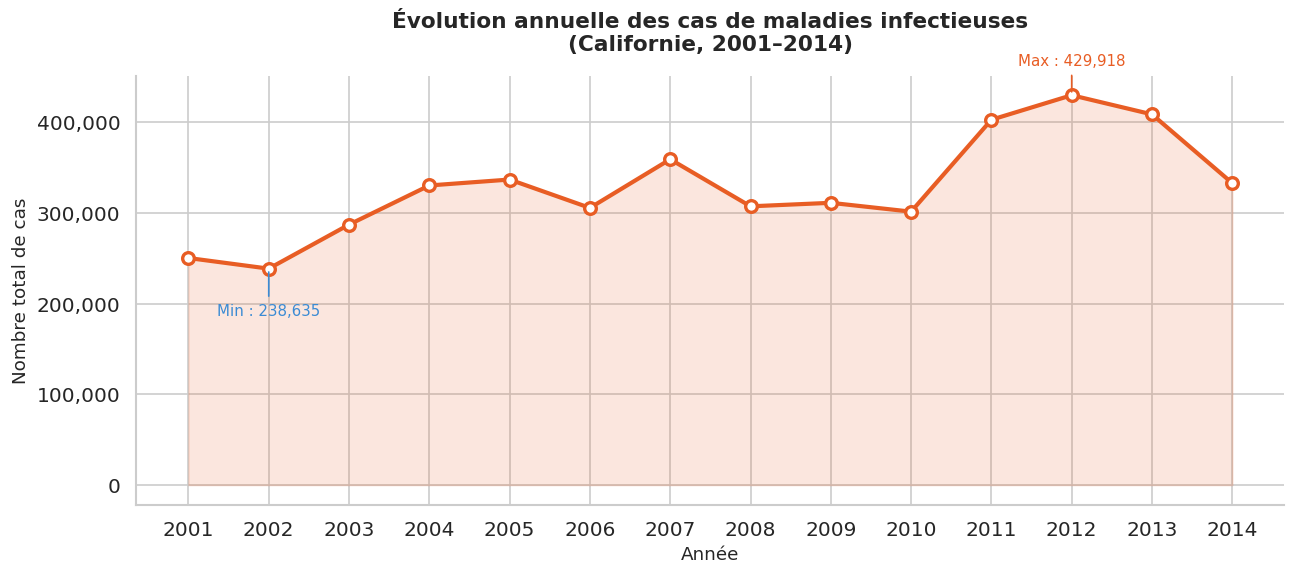

In [28]:
# GRAPHIQUE 2 — Évolution annuelle du nombre total de cas

print(" Graphique 2 : Évolution annuelle...")

evol = df.groupby("Year")["Count"].sum().reset_index()
evol.columns = ["Year", "Total_Cases"]

fig2, ax2 = plt.subplots(figsize=(11, 5))
ax2.fill_between(evol["Year"], evol["Total_Cases"], alpha=0.15, color="#E85D24")
ax2.plot(
    evol["Year"], evol["Total_Cases"],
    color="#E85D24", linewidth=2.5,
    marker="o", markersize=7,
    markerfacecolor="white", markeredgewidth=2
)

idx_max = evol["Total_Cases"].idxmax()
ax2.annotate(
    f"Max : {evol.loc[idx_max,'Total_Cases']:,.0f}",
    xy=(evol.loc[idx_max, "Year"], evol.loc[idx_max, "Total_Cases"]),
    xytext=(0, 18), textcoords="offset points",
    ha="center", fontsize=9, color="#E85D24",
    arrowprops=dict(arrowstyle="-", color="#E85D24", lw=1)
)
idx_min = evol["Total_Cases"].idxmin()
ax2.annotate(
    f"Min : {evol.loc[idx_min,'Total_Cases']:,.0f}",
    xy=(evol.loc[idx_min, "Year"], evol.loc[idx_min, "Total_Cases"]),
    xytext=(0, -28), textcoords="offset points",
    ha="center", fontsize=9, color="#3B8BD4",
    arrowprops=dict(arrowstyle="-", color="#3B8BD4", lw=1)
)

ax2.set_xlabel("Année", fontsize=11)
ax2.set_ylabel("Nombre total de cas", fontsize=11)
ax2.set_title("Évolution annuelle des cas de maladies infectieuses\n(Californie, 2001–2014)",
              fontsize=13, fontweight="bold", pad=15)
ax2.set_xticks(evol["Year"])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
fig2.tight_layout()
fig2.savefig(f"{OUTPUT_DIR}/02_evolution_annuelle.png")
print("   ✅ Sauvegardé dans outputs/graphs/")
plt.show()

 Graphique 3 : Heatmap corrélation...
    Sauvegardé dans outputs/graphs/


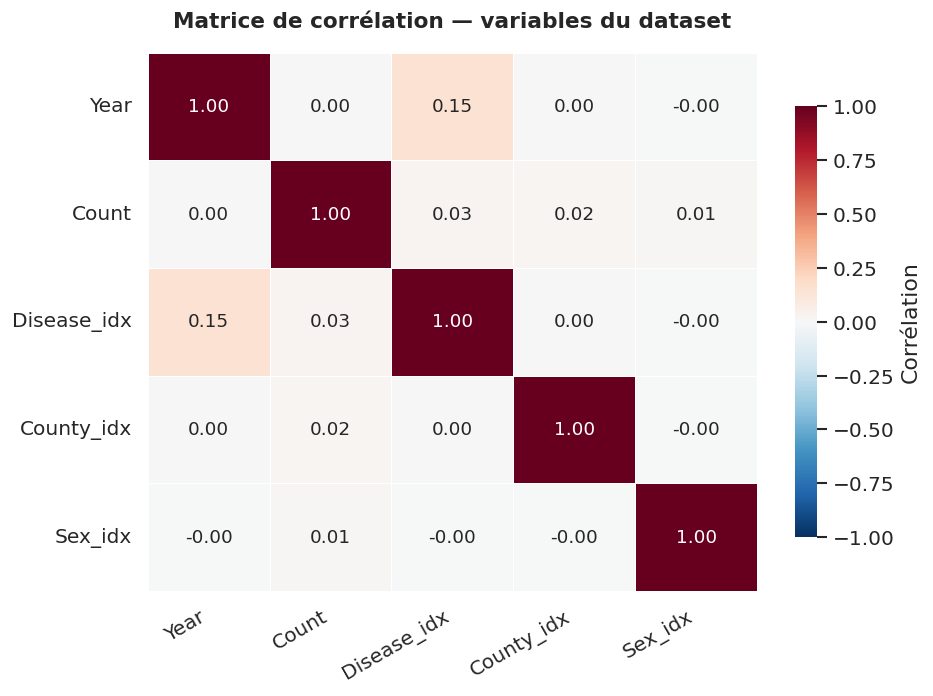

In [29]:
# GRAPHIQUE 3 — Heatmap corrélation

print(" Graphique 3 : Heatmap corrélation...")

num_cols = [c for c in ["Year", "Count", "Disease_idx", "County_idx", "Sex_idx"]
            if c in df.columns]
if len(num_cols) < 2:
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

corr_matrix = df[num_cols].corr()

fig3, ax3 = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix, ax=ax3,
    annot=True, fmt=".2f", annot_kws={"size": 11},
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Corrélation"}
)
ax3.set_title("Matrice de corrélation — variables du dataset",
              fontsize=13, fontweight="bold", pad=15)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=30, ha="right")
ax3.set_yticklabels(ax3.get_yticklabels(), rotation=0)
fig3.tight_layout()
fig3.savefig(f"{OUTPUT_DIR}/03_heatmap_correlation.png")
print("    Sauvegardé dans outputs/graphs/")
plt.show()

 Graphique 4 : Boxplot maladies...
   Sauvegardé dans outputs/graphs/


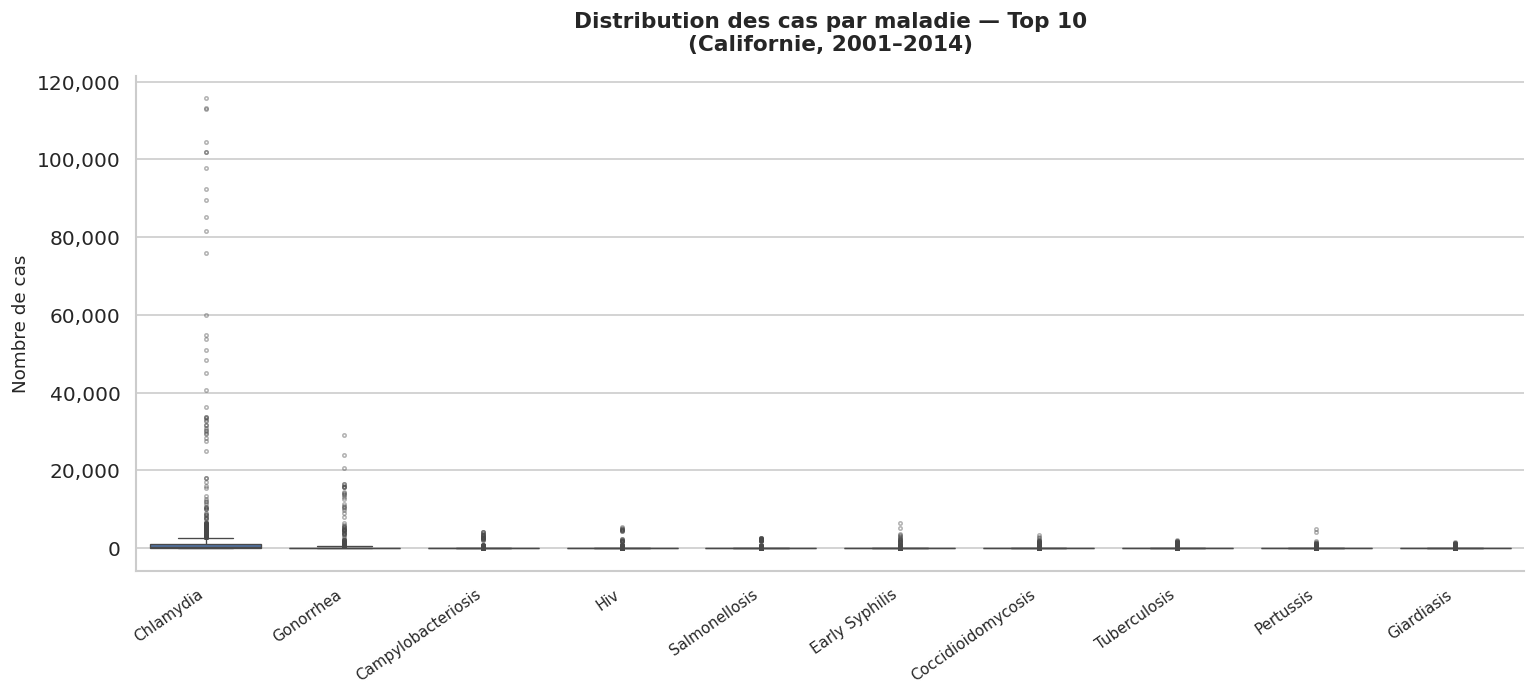

In [30]:
# GRAPHIQUE 4 — Boxplot Top 10 maladies

print(" Graphique 4 : Boxplot maladies...")

top10_names = (
    df.groupby("Disease")["Count"]
    .sum().sort_values(ascending=False)
    .head(10).index.tolist()
)
df_top10 = df[df["Disease"].isin(top10_names)].copy()

fig4, ax4 = plt.subplots(figsize=(13, 6))
sns.boxplot(
    data=df_top10, x="Disease", y="Count",
    palette="RdYlBu_r", ax=ax4,
    order=top10_names,
    flierprops=dict(marker="o", markersize=2, alpha=0.4),
    linewidth=0.8
)
ax4.set_xlabel("", fontsize=11)
ax4.set_ylabel("Nombre de cas", fontsize=11)
ax4.set_title("Distribution des cas par maladie — Top 10\n(Californie, 2001–2014)",
              fontsize=13, fontweight="bold", pad=15)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=35, ha="right", fontsize=9)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
fig4.tight_layout()
fig4.savefig(f"{OUTPUT_DIR}/04_boxplot_maladies.png")
print("   Sauvegardé dans outputs/graphs/")
plt.show()

 Graphique 5 : Top 10 comtés...
   Sauvegardé dans outputs/graphs/


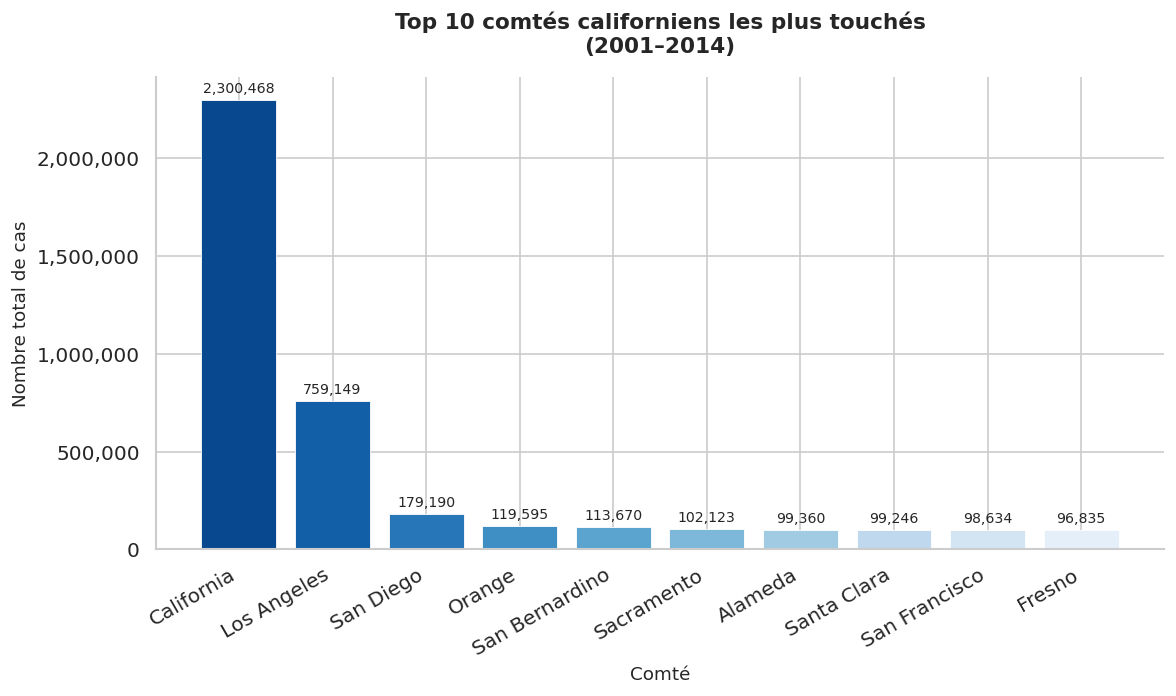

In [31]:
# GRAPHIQUE 5 — Top 10 comtés

print(" Graphique 5 : Top 10 comtés...")

top10_county = (
    df.groupby("County")["Count"]
    .sum().sort_values(ascending=False)
    .head(10).reset_index()
)
top10_county.columns = ["County", "Total_Cases"]

fig5, ax5 = plt.subplots(figsize=(10, 6))
palette5 = sns.color_palette("Blues_r", n_colors=10)
bars5 = ax5.bar(
    top10_county["County"],
    top10_county["Total_Cases"],
    color=palette5, edgecolor="white", linewidth=0.5
)
for bar, val in zip(bars5, top10_county["Total_Cases"]):
    ax5.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + top10_county["Total_Cases"].max() * 0.01,
        f"{val:,.0f}", ha="center", va="bottom", fontsize=8.5
    )
ax5.set_xlabel("Comté", fontsize=11)
ax5.set_ylabel("Nombre total de cas", fontsize=11)
ax5.set_title("Top 10 comtés californiens les plus touchés\n(2001–2014)",
              fontsize=13, fontweight="bold", pad=15)
ax5.set_xticklabels(top10_county["County"], rotation=30, ha="right")
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
fig5.tight_layout()
fig5.savefig(f"{OUTPUT_DIR}/05_top10_comtes.png")
print("   Sauvegardé dans outputs/graphs/")
plt.show()

 Graphique 6 : Répartition par sexe...
   Sauvegardé dans outputs/graphs/


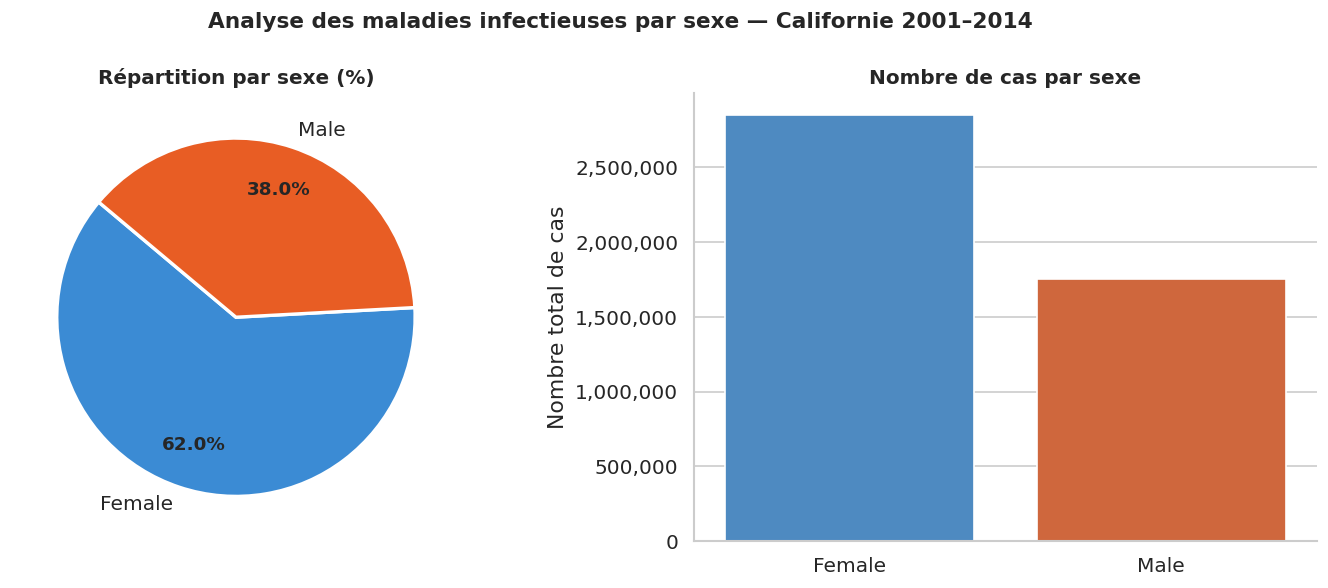

In [32]:
# GRAPHIQUE 6 — Répartition par sexe

print(" Graphique 6 : Répartition par sexe...")

sex_data = (
    df[df["Sex"].str.lower() != "total"]
    .groupby("Sex")["Count"].sum().reset_index()
)

fig6, (ax6a, ax6b) = plt.subplots(1, 2, figsize=(12, 5))
colors6 = ["#3B8BD4", "#E85D24"]

wedges, texts, autotexts = ax6a.pie(
    sex_data["Count"],
    labels=sex_data["Sex"],
    autopct="%1.1f%%",
    colors=colors6,
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
ax6a.set_title("Répartition par sexe (%)", fontsize=12, fontweight="bold")

sns.barplot(data=sex_data, x="Sex", y="Count",
            palette=colors6, ax=ax6b, edgecolor="white")
ax6b.set_title("Nombre de cas par sexe", fontsize=12, fontweight="bold")
ax6b.set_xlabel("")
ax6b.set_ylabel("Nombre total de cas")
ax6b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

fig6.suptitle("Analyse des maladies infectieuses par sexe — Californie 2001–2014",
              fontsize=13, fontweight="bold")
fig6.tight_layout()
fig6.savefig(f"{OUTPUT_DIR}/06_repartition_sexe.png")
print("   Sauvegardé dans outputs/graphs/")
plt.show()

 Graphique 7 : Évolution Top 5 maladies...
   Sauvegardé dans outputs/graphs/


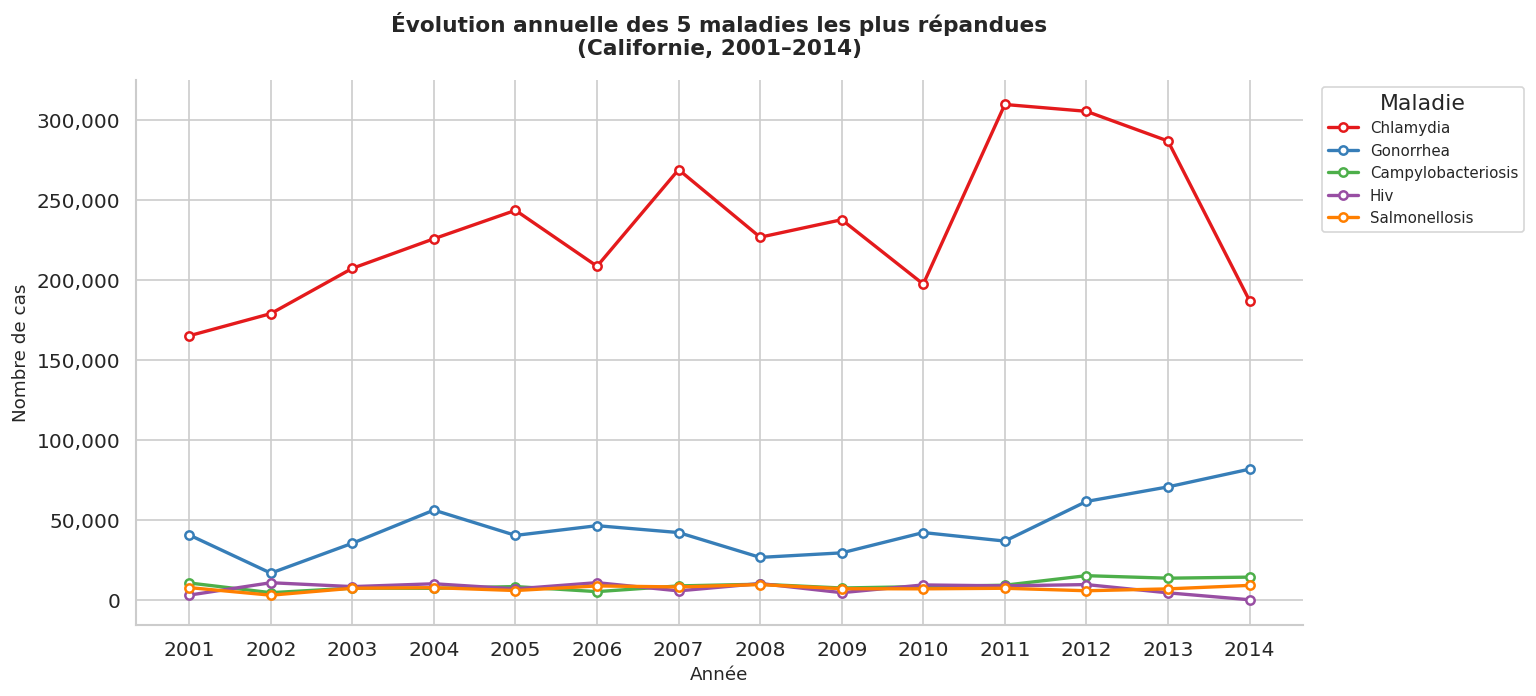

In [33]:
# GRAPHIQUE 7 — Évolution Top 5 maladies par année

print(" Graphique 7 : Évolution Top 5 maladies...")

top5_names = (
    df.groupby("Disease")["Count"]
    .sum().sort_values(ascending=False)
    .head(5).index.tolist()
)
evol_top5 = (
    df[df["Disease"].isin(top5_names)]
    .groupby(["Year", "Disease"])["Count"]
    .sum().reset_index()
)

fig7, ax7 = plt.subplots(figsize=(13, 6))
palette7 = sns.color_palette("Set1", n_colors=5)

for i, disease in enumerate(top5_names):
    data_d = evol_top5[evol_top5["Disease"] == disease]
    ax7.plot(
        data_d["Year"], data_d["Count"],
        label=disease, color=palette7[i],
        linewidth=2, marker="o", markersize=5,
        markerfacecolor="white", markeredgewidth=1.5
    )

ax7.set_xlabel("Année", fontsize=11)
ax7.set_ylabel("Nombre de cas", fontsize=11)
ax7.set_title("Évolution annuelle des 5 maladies les plus répandues\n(Californie, 2001–2014)",
              fontsize=13, fontweight="bold", pad=15)
ax7.legend(title="Maladie", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax7.set_xticks(evol_top5["Year"].unique())
ax7.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
fig7.tight_layout()
fig7.savefig(f"{OUTPUT_DIR}/07_evolution_top5.png")
print("   Sauvegardé dans outputs/graphs/")
plt.show()

 Graphique 8 : Heatmap Year × Disease...
    Sauvegardé dans outputs/graphs/


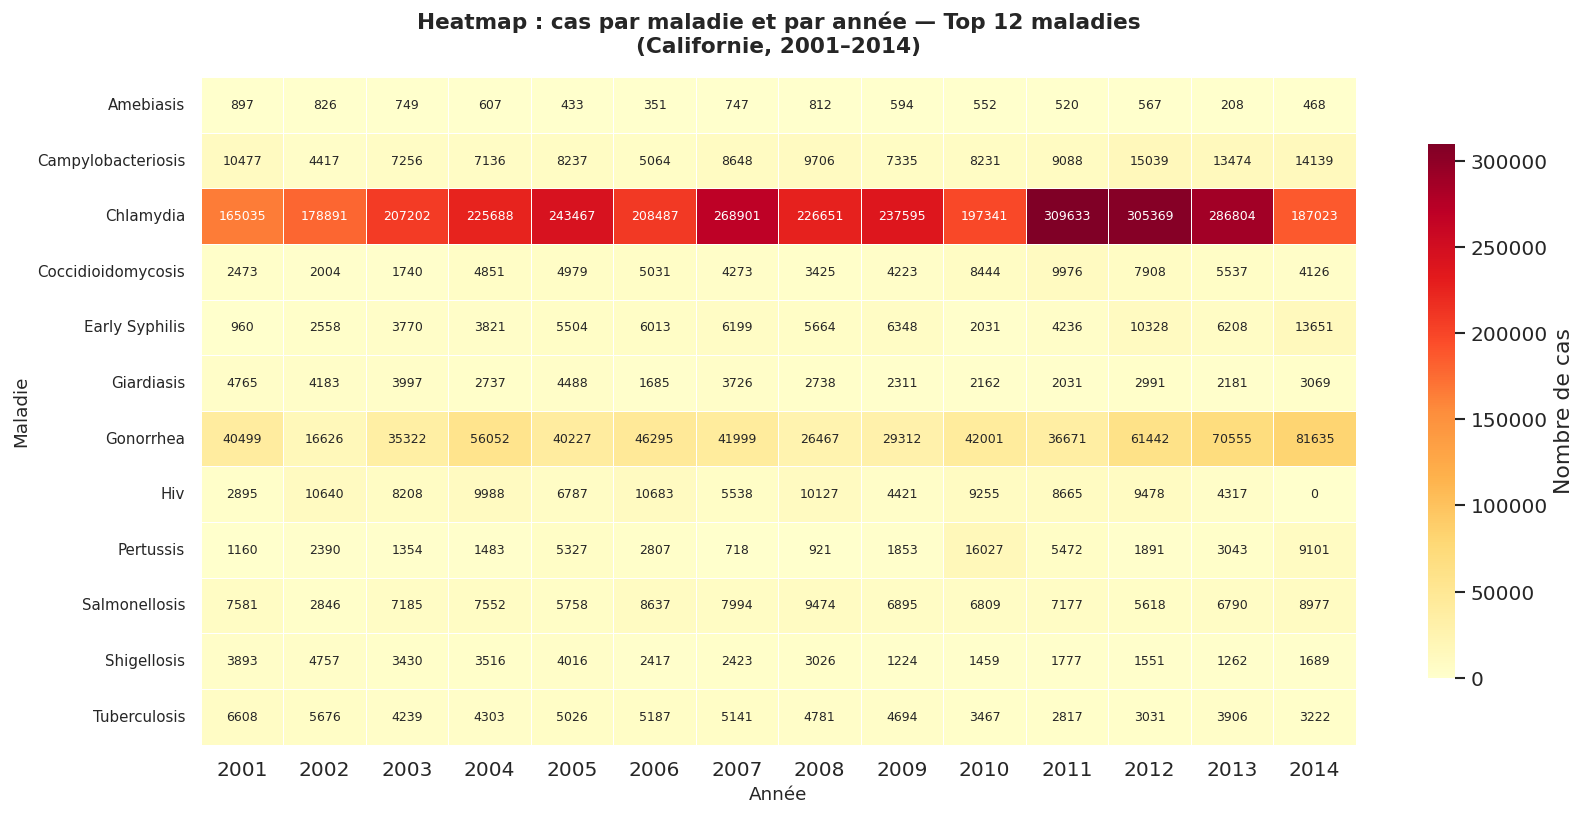

In [34]:
# GRAPHIQUE 8 — Heatmap Year × Disease
print(" Graphique 8 : Heatmap Year × Disease...")

top12_names = (
    df.groupby("Disease")["Count"]
    .sum().sort_values(ascending=False)
    .head(12).index.tolist()
)
pivot = (
    df[df["Disease"].isin(top12_names)]
    .groupby(["Disease", "Year"])["Count"]
    .sum()
    .unstack(fill_value=0)
)

fig8, ax8 = plt.subplots(figsize=(14, 7))
sns.heatmap(
    pivot, ax=ax8,
    cmap="YlOrRd",
    annot=True, fmt=".0f", annot_kws={"size": 7.5},
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Nombre de cas", "shrink": 0.8}
)
ax8.set_title("Heatmap : cas par maladie et par année — Top 12 maladies\n(Californie, 2001–2014)",
              fontsize=13, fontweight="bold", pad=15)
ax8.set_xlabel("Année", fontsize=11)
ax8.set_ylabel("Maladie", fontsize=11)
ax8.set_yticklabels(ax8.get_yticklabels(), rotation=0, fontsize=9)
fig8.tight_layout()
fig8.savefig(f"{OUTPUT_DIR}/08_heatmap_year_disease.png")
print("    Sauvegardé dans outputs/graphs/")
plt.show()

In [35]:
print("\n" + "=" * 50)
print("  ✅ EDA terminée — 8 graphiques affichés et sauvegardés")
print(f"  📁 Dossier de sortie : {OUTPUT_DIR}/")
print("=" * 50)
print("\n→ Passe maintenant à 04_model_train.py")


  ✅ EDA terminée — 8 graphiques affichés et sauvegardés
  📁 Dossier de sortie : outputs/graphs/

→ Passe maintenant à 04_model_train.py


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
import joblib
import warnings
import os

warnings.filterwarnings("ignore")

In [37]:
OUTPUT_DIR  = "outputs/graphs"
MODELS_DIR  = "models"
PRED_DIR    = "outputs/predictions"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PRED_DIR,   exist_ok=True)

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi"       : 120,
    "savefig.dpi"      : 150,
    "savefig.bbox"     : "tight",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

FEATURE_COLS = ["Disease_idx", "County_idx", "Year", "Sex_idx", "Decade", "Year_norm"]
TARGET_COL   = "Count"
COLORS       = {"XGBoost": "#E85D24", "RandomForest": "#3B8BD4", "GradientBoosting": "#1D9E75"}

print("=" * 60)
print("  PFE Santé Publique — Évaluation des modèles ML")
print("=" * 60)

  PFE Santé Publique — Évaluation des modèles ML


In [38]:
print("\n" + "-" * 50)
print("  CHARGEMENT DES DONNÉES")
print("-" * 50)

# Re-define get_spark_single_csv_path if not globally available, or assume it is from b1grvvU3Uck5
# For robustness, let's include it here as well for this independent script
import os

def get_spark_single_csv_path(spark_output_dir):
    files = os.listdir(spark_output_dir)
    csv_files = [f for f in files if f.startswith('part-') and f.endswith('.csv')]
    if len(csv_files) == 1:
        return os.path.join(spark_output_dir, csv_files[0])
    elif len(csv_files) > 1:
        raise ValueError(f"Multiple CSV part files found in {spark_output_dir}. Please inspect the output.")
    else:
        raise FileNotFoundError(f"No CSV part files found in {spark_output_dir}.")

try:
    # Use the correct paths for the processed CSVs, assuming ABS_LOCAL_OUTPUT is available
    # ABS_LOCAL_OUTPUT is from 1ZMrw_dNMKcz: /content/data/processed
    processed_train_csv_dir = os.path.join(ABS_LOCAL_OUTPUT, "csv", "train")
    processed_test_csv_dir  = os.path.join(ABS_LOCAL_OUTPUT, "csv", "test")

    train_file_path = get_spark_single_csv_path(processed_train_csv_dir)
    test_file_path  = get_spark_single_csv_path(processed_test_csv_dir)

    df_train = pd.read_csv(train_file_path)
    df_test  = pd.read_csv(test_file_path)
    print(f" Train : {df_train.shape[0]:,} lignes | Test : {df_test.shape[0]:,} lignes (depuis fichiers traités)")
except (FileNotFoundError, ValueError) as e:
    print(f"  CSV nettoyé introuvable ou erreur de lecture ({e}) → Tentative de chargement CSV brut")
    try:
        # Fallback to raw Kaggle CSV, using the correct variables
        df_train = pd.read_csv(PATH_LOCAL_TRAIN)
        df_test  = pd.read_csv(PATH_LOCAL_TEST)
        df_train["Count"] = pd.to_numeric(df_train["Count"], errors="coerce").fillna(0).astype(int)
        df_test["Count"]  = pd.to_numeric(df_test["Count"],  errors="coerce").fillna(0).astype(int)
        print(f" Train : {df_train.shape[0]:,} lignes | Test : {df_test.shape[0]:,} lignes (depuis fichiers bruts)")
    except FileNotFoundError as e_raw:
        print(f"  Erreur fatale: Fichier CSV brut introuvable non plus ({e_raw})")
        raise # Re-raise if even the raw file cannot be found

# Préparer X et y
available_features = [c for c in FEATURE_COLS if c in df_train.columns]
if not available_features:
    # Fallback : encoder à la volée si les idx ne sont pas présents
    from sklearn.preprocessing import LabelEncoder
    for col in ["Disease", "County", "Sex"]:
        if col in df_train.columns:
            le = LabelEncoder()
            df_train[f"{col}_idx"] = le.fit_transform(df_train[col].astype(str))
            df_test[f"{col}_idx"]  = le.transform(
                df_test[col].astype(str).map(
                    lambda x: x if x in le.classes_ else le.classes_[0]))
    if "Decade" not in df_train.columns:
        df_train["Decade"]    = (df_train["Year"] // 10 * 10).astype(int)
        df_test["Decade"]     = (df_test["Year"]  // 10 * 10).astype(int)
    if "Year_norm" not in df_train.columns:
        df_train["Year_norm"] = (df_train["Year"] - 2001).astype(float)
        df_test["Year_norm"]  = (df_test["Year"]  - 2001).astype(float)
    available_features = [c for c in FEATURE_COLS if c in df_train.columns]

X_train = df_train[available_features].fillna(0)
y_train = df_train[TARGET_COL].fillna(0)
X_test  = df_test[available_features].fillna(0)
y_test  = df_test[TARGET_COL].fillna(0)

print(f"   Features utilisées : {available_features}")
print(f"   X_train : {X_train.shape} | X_test : {X_test.shape}")


--------------------------------------------------
  CHARGEMENT DES DONNÉES
--------------------------------------------------
 Train : 75,614 lignes | Test : 18,904 lignes (depuis fichiers traités)
   Features utilisées : ['Disease_idx', 'County_idx', 'Year', 'Sex_idx', 'Decade', 'Year_norm']
   X_train : (75614, 6) | X_test : (18904, 6)


In [39]:
# BLOC 2 — Chargement ou entraînement des modèles

print("\n" + "-" * 50)
print("  CHARGEMENT / ENTRAÎNEMENT DES MODÈLES")
print("-" * 50)

def load_or_train(name, model, path):
    if os.path.exists(path):
        m = joblib.load(path)
        print(f" {name} chargé depuis {path}")
    else:
        print(f"  {name} introuvable → entraînement en cours...")
        model.fit(X_train, y_train)
        os.makedirs(MODELS_DIR, exist_ok=True)
        joblib.dump(model, path)
        m = model
        print(f" {name} entraîné et sauvegardé")
    return m

models = {
    "XGBoost": load_or_train(
        "XGBoost",
        XGBRegressor(n_estimators=200, learning_rate=0.1,
                     max_depth=6, random_state=42, verbosity=0),
        f"{MODELS_DIR}/xgboost_model.pkl"
    ),
    "RandomForest": load_or_train(
        "RandomForest",
        RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        f"{MODELS_DIR}/random_forest_model.pkl"
    ),
    "GradientBoosting": load_or_train(
        "GradientBoosting",
        GradientBoostingRegressor(n_estimators=150, learning_rate=0.1,
                                  max_depth=5, random_state=42),
        f"{MODELS_DIR}/gradient_boosting_model.pkl"
    ),
}


--------------------------------------------------
  CHARGEMENT / ENTRAÎNEMENT DES MODÈLES
--------------------------------------------------
  XGBoost introuvable → entraînement en cours...
 XGBoost entraîné et sauvegardé
  RandomForest introuvable → entraînement en cours...
 RandomForest entraîné et sauvegardé
  GradientBoosting introuvable → entraînement en cours...
 GradientBoosting entraîné et sauvegardé


In [40]:
# BLOC 3 — Calcul des métriques pour chaque modèle

print("\n" + "-" * 50)
print("  CALCUL DES MÉTRIQUES")
print("-" * 50)

results = {}
predictions = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_pred = np.maximum(y_pred, 0)   # les cas ne peuvent pas être négatifs

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    results[name]     = {"RMSE": rmse, "MAE": mae, "R²": r2}
    predictions[name] = y_pred

    print(f"\n  [{name}]")
    print(f"    RMSE : {rmse:,.2f}  (plus bas = meilleur)")
    print(f"    MAE  : {mae:,.2f}  (plus bas = meilleur)")
    print(f"    R²   : {r2:.4f}  (plus proche de 1 = meilleur)")

# Identifier le meilleur modèle (R² le plus élevé)
best_name = max(results, key=lambda k: results[k]["R²"])
print(f"\n Meilleur modèle : {best_name} (R² = {results[best_name]['R²']:.4f})")



--------------------------------------------------
  CALCUL DES MÉTRIQUES
--------------------------------------------------

  [XGBoost]
    RMSE : 115.02  (plus bas = meilleur)
    MAE  : 16.61  (plus bas = meilleur)
    R²   : 0.9927  (plus proche de 1 = meilleur)

  [RandomForest]
    RMSE : 73.35  (plus bas = meilleur)
    MAE  : 5.64  (plus bas = meilleur)
    R²   : 0.9970  (plus proche de 1 = meilleur)

  [GradientBoosting]
    RMSE : 217.64  (plus bas = meilleur)
    MAE  : 28.46  (plus bas = meilleur)
    R²   : 0.9740  (plus proche de 1 = meilleur)

 Meilleur modèle : RandomForest (R² = 0.9970)



 Graphique 1 : Comparaison des métriques...
    Sauvegardé


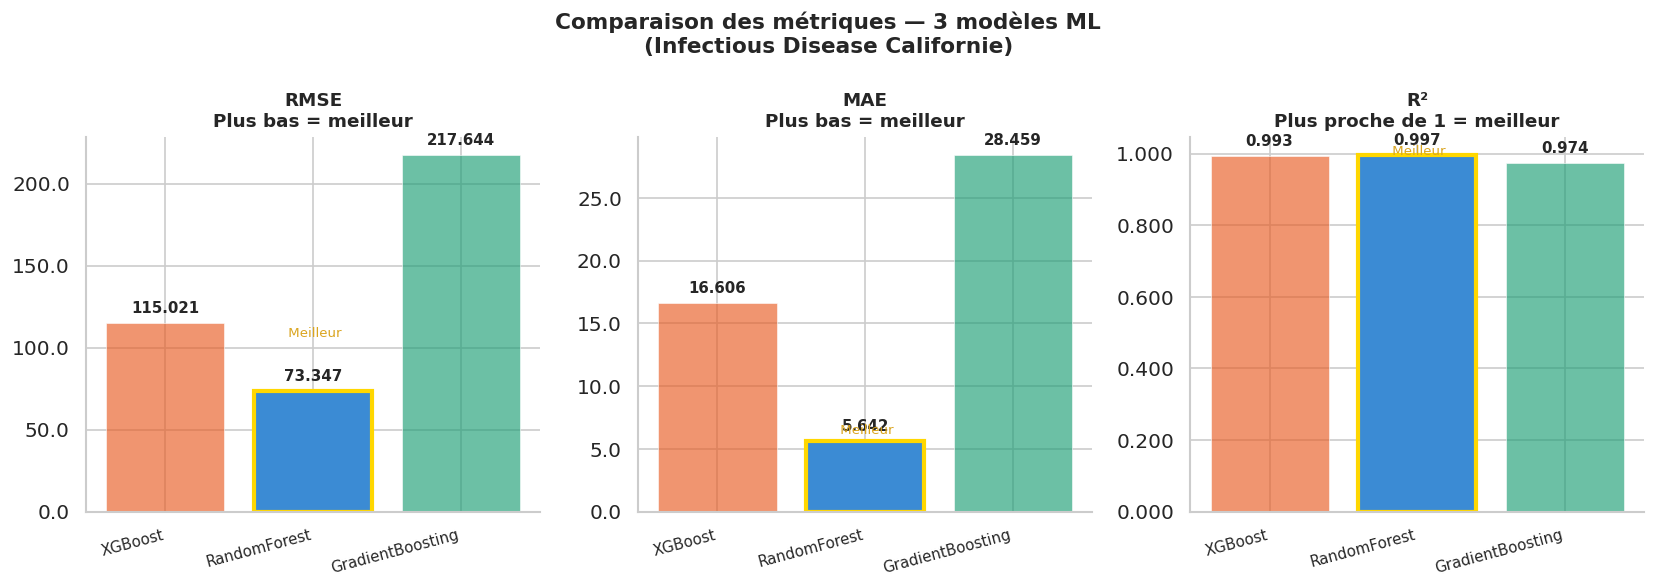

In [41]:
# GRAPHIQUE 1 — Tableau comparatif des métriques (3 modèles)

print("\n Graphique 1 : Comparaison des métriques...")

df_metrics = pd.DataFrame(results).T.reset_index()
df_metrics.columns = ["Modèle", "RMSE", "MAE", "R²"]

fig1, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics_info = [
    ("RMSE", "Plus bas = meilleur", True),
    ("MAE",  "Plus bas = meilleur", True),
    ("R²",   "Plus proche de 1 = meilleur", False),
]

for ax, (metric, subtitle, lower_better) in zip(axes, metrics_info):
    vals   = df_metrics[metric].values
    colors = [COLORS[m] for m in df_metrics["Modèle"]]

    # Mettre en valeur le meilleur
    best_idx = vals.argmin() if lower_better else vals.argmax()
    edge_widths = [2.5 if i == best_idx else 0.5 for i in range(len(vals))]
    alphas      = [1.0  if i == best_idx else 0.65 for i in range(len(vals))]

    bars = ax.bar(df_metrics["Modèle"], vals, color=colors,
                  edgecolor=["gold" if i == best_idx else "white"
                              for i in range(len(vals))],
                  linewidth=edge_widths, alpha=1.0)

    for bar, val, alpha in zip(bars, vals, alphas):
        bar.set_alpha(alpha)
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + vals.max() * 0.02,
                f"{val:.3f}", ha="center", va="bottom",
                fontsize=9, fontweight="bold")

    ax.set_title(f"{metric}\n{subtitle}", fontsize=11, fontweight="bold")
    ax.set_xticklabels(df_metrics["Modèle"], rotation=15, ha="right", fontsize=9)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:,.1f}") if metric != "R²"
        else mticker.FuncFormatter(lambda x, _: f"{x:.3f}")
    )

    # Annotation du meilleur
    ax.annotate(" Meilleur", xy=(best_idx, vals[best_idx]),
                xytext=(0, vals.max() * 0.15), textcoords="offset points",
                ha="center", fontsize=8, color="goldenrod")

fig1.suptitle("Comparaison des métriques — 3 modèles ML\n(Infectious Disease Californie)",
              fontsize=13, fontweight="bold")
fig1.tight_layout()
fig1.savefig(f"{OUTPUT_DIR}/10_comparaison_metriques.png")
print("    Sauvegardé")
plt.show()

 Graphique 2 : Scatter réel vs prédit...
    Sauvegardé


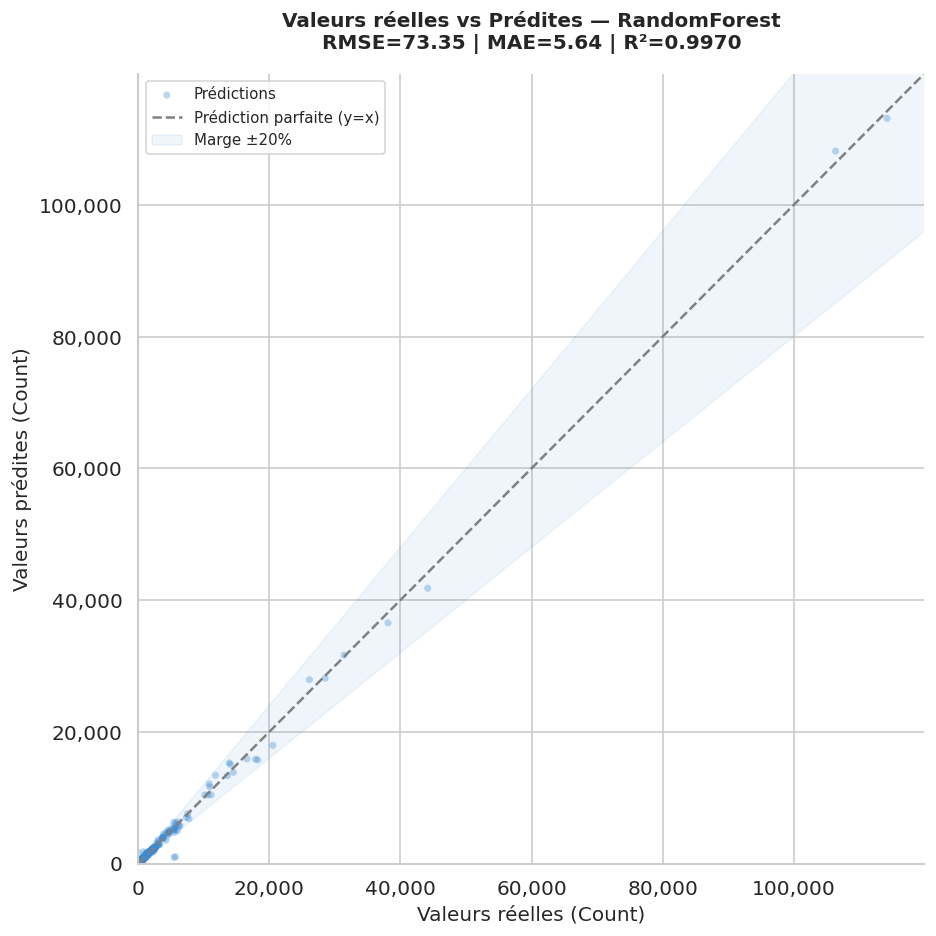

In [42]:
# GRAPHIQUE 2 — Scatter plot : Réel vs Prédit (meilleur modèle)

print(" Graphique 2 : Scatter réel vs prédit...")

y_pred_best = predictions[best_name]
color_best  = COLORS[best_name]

fig2, ax2 = plt.subplots(figsize=(8, 8))

ax2.scatter(y_test, y_pred_best, alpha=0.35, s=18,
            color=color_best, edgecolors="none", label="Prédictions")

# Ligne parfaite y=x
lim_max = max(y_test.max(), y_pred_best.max()) * 1.05
ax2.plot([0, lim_max], [0, lim_max],
         color="gray", linestyle="--", linewidth=1.5,
         label="Prédiction parfaite (y=x)")

# Bandes d'erreur ±20%
ax2.fill_between([0, lim_max],
                 [0, lim_max * 0.8], [0, lim_max * 1.2],
                 alpha=0.08, color=color_best, label="Marge ±20%")

ax2.set_xlabel("Valeurs réelles (Count)", fontsize=12)
ax2.set_ylabel("Valeurs prédites (Count)", fontsize=12)
ax2.set_title(f"Valeurs réelles vs Prédites — {best_name}\n"
              f"RMSE={results[best_name]['RMSE']:,.2f} | "
              f"MAE={results[best_name]['MAE']:,.2f} | "
              f"R²={results[best_name]['R²']:.4f}",
              fontsize=12, fontweight="bold", pad=15)
ax2.set_xlim(0, lim_max)
ax2.set_ylim(0, lim_max)
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
fig2.tight_layout()
fig2.savefig(f"{OUTPUT_DIR}/11_scatter_reel_predit.png")
print("    Sauvegardé")
plt.show()

 Graphique 3 : Courbe des résidus...
    Sauvegardé


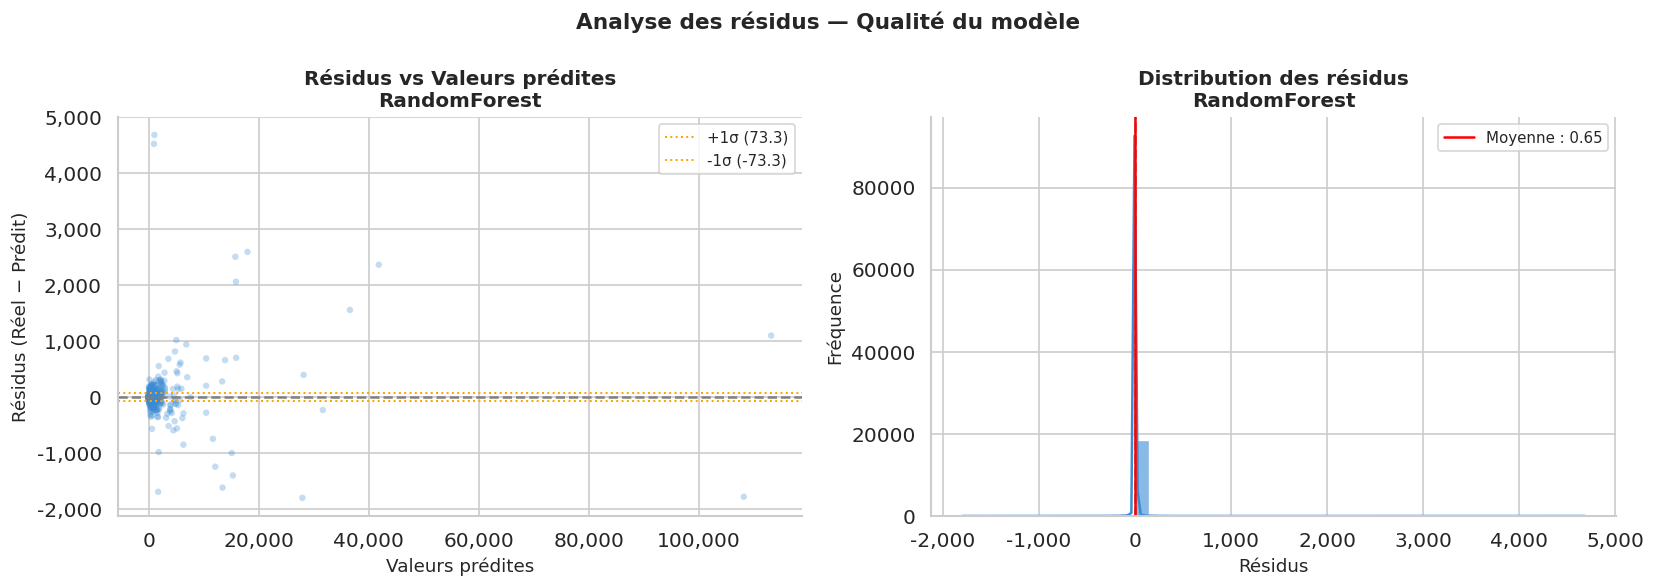

In [43]:
# GRAPHIQUE 3 — Courbe des résidus (meilleur modèle)

print(" Graphique 3 : Courbe des résidus...")

residuals = y_test.values - y_pred_best

fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(14, 5))

# Résidus vs valeurs prédites
ax3a.scatter(y_pred_best, residuals, alpha=0.3, s=15,
             color=color_best, edgecolors="none")
ax3a.axhline(0, color="gray", linestyle="--", linewidth=1.5)
ax3a.axhline(residuals.std(),  color="orange", linestyle=":", linewidth=1.2,
             label=f"+1σ ({residuals.std():,.1f})")
ax3a.axhline(-residuals.std(), color="orange", linestyle=":", linewidth=1.2,
             label=f"-1σ ({-residuals.std():,.1f})")
ax3a.set_xlabel("Valeurs prédites", fontsize=11)
ax3a.set_ylabel("Résidus (Réel − Prédit)", fontsize=11)
ax3a.set_title(f"Résidus vs Valeurs prédites\n{best_name}",
               fontsize=12, fontweight="bold")
ax3a.legend(fontsize=9)
ax3a.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax3a.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Distribution des résidus
sns.histplot(residuals, ax=ax3b, bins=40, kde=True,
             color=color_best, alpha=0.6, edgecolor="white")
ax3b.axvline(0, color="gray", linestyle="--", linewidth=1.5)
ax3b.axvline(residuals.mean(), color="red", linestyle="-", linewidth=1.5,
             label=f"Moyenne : {residuals.mean():,.2f}")
ax3b.set_xlabel("Résidus", fontsize=11)
ax3b.set_ylabel("Fréquence", fontsize=11)
ax3b.set_title(f"Distribution des résidus\n{best_name}",
               fontsize=12, fontweight="bold")
ax3b.legend(fontsize=9)
ax3b.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

fig3.suptitle("Analyse des résidus — Qualité du modèle",
              fontsize=13, fontweight="bold")
fig3.tight_layout()
fig3.savefig(f"{OUTPUT_DIR}/12_courbe_residus.png")
print("    Sauvegardé")
plt.show()

📊 Graphique 4 : Feature importance...
   ✅ Sauvegardé


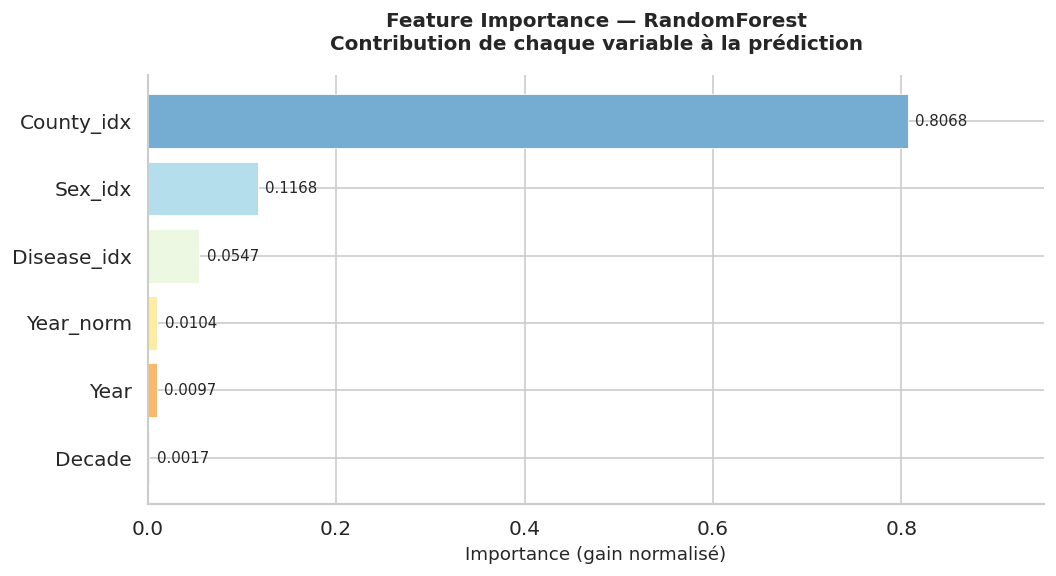


📋 Feature importance détaillée :
   ██████████████████████████████ County_idx      : 0.8068
   ████                           Sex_idx         : 0.1168
   ██                             Disease_idx     : 0.0547
                                  Year_norm       : 0.0104
                                  Year            : 0.0097
                                  Decade          : 0.0017


In [44]:
# GRAPHIQUE 4 — Feature Importance (meilleur modèle)

print("📊 Graphique 4 : Feature importance...")

best_model = models[best_name]

if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    feat_df = pd.DataFrame({
        "Feature"   : available_features,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    fig4, ax4 = plt.subplots(figsize=(9, 5))
    palette_imp = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(feat_df)))
    bars4 = ax4.barh(
        feat_df["Feature"][::-1],
        feat_df["Importance"][::-1],
        color=palette_imp[::-1],
        edgecolor="white", linewidth=0.5
    )
    for bar, val in zip(bars4, feat_df["Importance"][::-1]):
        ax4.text(bar.get_width() + feat_df["Importance"].max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f"{val:.4f}", va="center", ha="left", fontsize=9)

    ax4.set_xlabel("Importance (gain normalisé)", fontsize=11)
    ax4.set_title(f"Feature Importance — {best_name}\n"
                  f"Contribution de chaque variable à la prédiction",
                  fontsize=12, fontweight="bold", pad=15)
    ax4.set_xlim(0, feat_df["Importance"].max() * 1.18)
    fig4.tight_layout()
    fig4.savefig(f"{OUTPUT_DIR}/13_feature_importance.png")
    print("   ✅ Sauvegardé")
    plt.show()

    print("\n📋 Feature importance détaillée :")
    for _, row in feat_df.iterrows():
        bar_len = int(row["Importance"] / feat_df["Importance"].max() * 30)
        print(f"   {'█' * bar_len:<30} {row['Feature']:<15} : {row['Importance']:.4f}")
else:
    print("   ⚠️  Ce modèle ne supporte pas feature_importances_")

📊 Graphique 5 : Prédictions vs réalité dans le temps...
   ✅ Sauvegardé


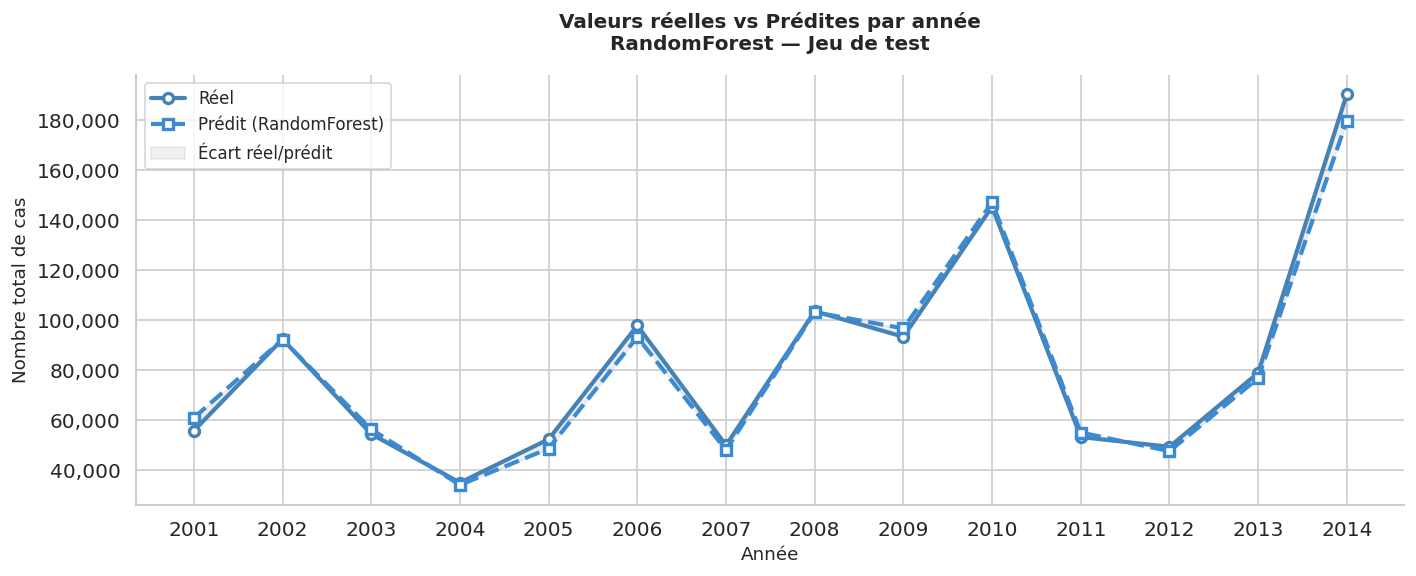

In [45]:
# GRAPHIQUE 5 — Prédictions vs réalité dans le temps (Year)

print("📊 Graphique 5 : Prédictions vs réalité dans le temps...")

df_temp = df_test.copy()
df_temp["Predicted"] = predictions[best_name]

evol_real = df_temp.groupby("Year")[TARGET_COL].sum().reset_index()
evol_pred = df_temp.groupby("Year")["Predicted"].sum().reset_index()

fig5, ax5 = plt.subplots(figsize=(12, 5))

ax5.plot(evol_real["Year"], evol_real[TARGET_COL],
         color="steelblue", linewidth=2.5, marker="o", markersize=6,
         markerfacecolor="white", markeredgewidth=2, label="Réel")
ax5.plot(evol_pred["Year"], evol_pred["Predicted"],
         color=color_best, linewidth=2.5, marker="s", markersize=6,
         markerfacecolor="white", markeredgewidth=2, label=f"Prédit ({best_name})",
         linestyle="--")
ax5.fill_between(
    evol_real["Year"],
    evol_real[TARGET_COL], evol_pred["Predicted"],
    alpha=0.12, color="gray", label="Écart réel/prédit"
)

ax5.set_xlabel("Année", fontsize=11)
ax5.set_ylabel("Nombre total de cas", fontsize=11)
ax5.set_title(f"Valeurs réelles vs Prédites par année\n{best_name} — Jeu de test",
              fontsize=12, fontweight="bold", pad=15)
ax5.legend(fontsize=10)
ax5.set_xticks(evol_real["Year"].unique())
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
fig5.tight_layout()
fig5.savefig(f"{OUTPUT_DIR}/14_predictions_temporelles.png")
print("   ✅ Sauvegardé")
plt.show()

📊 Graphique 6 : Scatter comparatif 3 modèles...
   ✅ Sauvegardé


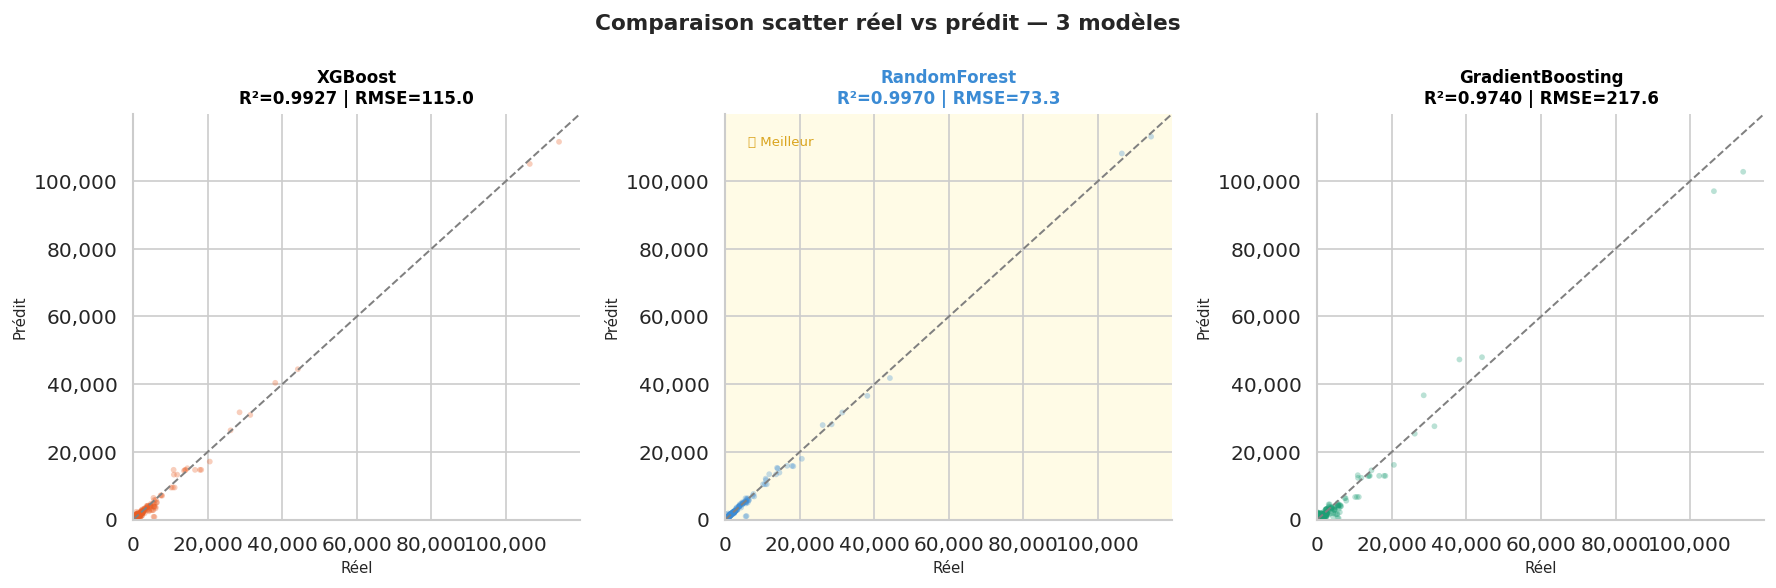

In [46]:
# GRAPHIQUE 6 — Comparaison scatter les 3 modèles côte à côte

print("📊 Graphique 6 : Scatter comparatif 3 modèles...")

fig6, axes6 = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, y_pred) in zip(axes6, predictions.items()):
    color = COLORS[name]
    ax.scatter(y_test, y_pred, alpha=0.3, s=12,
               color=color, edgecolors="none")
    lim = max(y_test.max(), y_pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], color="gray",
            linestyle="--", linewidth=1.2)
    r2 = results[name]["R²"]
    rmse = results[name]["RMSE"]
    ax.set_title(f"{name}\nR²={r2:.4f} | RMSE={rmse:,.1f}",
                 fontsize=10, fontweight="bold",
                 color=color if name == best_name else "black")
    ax.set_xlabel("Réel", fontsize=9)
    ax.set_ylabel("Prédit", fontsize=9)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    if name == best_name:
        ax.set_facecolor("#fffbe6")
        ax.text(0.05, 0.92, "⭐ Meilleur",
                transform=ax.transAxes, fontsize=8, color="goldenrod")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

fig6.suptitle("Comparaison scatter réel vs prédit — 3 modèles",
              fontsize=13, fontweight="bold")
fig6.tight_layout()
fig6.savefig(f"{OUTPUT_DIR}/15_scatter_3_modeles.png")
print("   ✅ Sauvegardé")
plt.show()

In [47]:
# BLOC FINAL — Export prédictions + résumé

print("\n" + "-" * 50)
print("  EXPORT DES PRÉDICTIONS")
print("-" * 50)

df_export = df_test[["Disease", "County", "Year", "Sex", TARGET_COL]].copy()
for name, y_pred in predictions.items():
    df_export[f"Pred_{name}"] = np.maximum(y_pred, 0).round(0).astype(int)
df_export["Pred_Best"] = df_export[f"Pred_{best_name}"]
df_export.to_csv(f"{PRED_DIR}/predictions.csv", index=False)
print(f"✅ Prédictions exportées : {PRED_DIR}/predictions.csv")

print("\n" + "=" * 60)
print("  RÉSUMÉ FINAL — ÉVALUATION DES MODÈLES")
print("=" * 60)
print(f"\n  {'Modèle':<20} {'RMSE':>10} {'MAE':>10} {'R²':>10}")
print("  " + "-" * 52)
for name, m in results.items():
    star = " ⭐" if name == best_name else ""
    print(f"  {name:<20} {m['RMSE']:>10,.2f} {m['MAE']:>10,.2f} {m['R²']:>10.4f}{star}")

print(f"\n  Meilleur modèle : {best_name}")
print(f"  R²   = {results[best_name]['R²']:.4f}  → "
      f"le modèle explique {results[best_name]['R²']*100:.1f}% de la variance")
print(f"  RMSE = {results[best_name]['RMSE']:,.2f} cas en moyenne d'erreur")
print(f"  MAE  = {results[best_name]['MAE']:,.2f}  cas d'erreur absolue moyenne")
print("\n  Graphiques générés :")
graphs = [
    "10_comparaison_metriques.png",
    "11_scatter_reel_predit.png",
    "12_courbe_residus.png",
    "13_feature_importance.png",
    "14_predictions_temporelles.png",
    "15_scatter_3_modeles.png",
]
for g in graphs:
    print(f"  ✅ {OUTPUT_DIR}/{g}")
print("=" * 60)
print("\n→ Passe maintenant à 06_dashboard.py (Étape 6 — Streamlit)")


--------------------------------------------------
  EXPORT DES PRÉDICTIONS
--------------------------------------------------
✅ Prédictions exportées : outputs/predictions/predictions.csv

  RÉSUMÉ FINAL — ÉVALUATION DES MODÈLES

  Modèle                     RMSE        MAE         R²
  ----------------------------------------------------
  XGBoost                  115.02      16.61     0.9927
  RandomForest              73.35       5.64     0.9970 ⭐
  GradientBoosting         217.64      28.46     0.9740

  Meilleur modèle : RandomForest
  R²   = 0.9970  → le modèle explique 99.7% de la variance
  RMSE = 73.35 cas en moyenne d'erreur
  MAE  = 5.64  cas d'erreur absolue moyenne

  Graphiques générés :
  ✅ outputs/graphs/10_comparaison_metriques.png
  ✅ outputs/graphs/11_scatter_reel_predit.png
  ✅ outputs/graphs/12_courbe_residus.png
  ✅ outputs/graphs/13_feature_importance.png
  ✅ outputs/graphs/14_predictions_temporelles.png
  ✅ outputs/graphs/15_scatter_3_modeles.png

→ Passe main